# Activity 1

In [24]:
import numpy as np

def load_chain(path: str) -> tuple:
    transition_matrix = np.load(path)
    n_states = transition_matrix.shape[0]
    states = tuple(range(0, n_states, 1))
    return (states, transition_matrix)

In [25]:
M = load_chain('example.npy')
print(M)

print('Number of states:', len(M[0]))
print('Type of states:', type(M[0][0]))
print('First state:', M[0][0])
print('\nTransition probability matrix (type):', type(M[1]))
print('Transition probability matrix (dimension):', M[1].shape)

((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10), array([[0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0. , 0.1, 0.1, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ]]))
Number of states: 11
Type of states: <class 'int'>
First state: 0

Transition probability matrix (type): <class 'numpy.ndarray'>
Transition probability matrix (dimension): (11, 11)


# Activity 2


In [26]:
def prob_trajectory(mc : tuple, trajectory : tuple[str]) -> float:
    prob = 1
    n_states_traj = len(trajectory)
    transition_matrix = mc[1]
    for i in range(0, n_states_traj-1):
        prob *= transition_matrix[int(trajectory[i]), int(trajectory[i+1])]
    return prob

In [27]:
print(M)

print("Prob. of trajectory 3-4-5-6-7-8:", prob_trajectory(M, ('3', '4', '5', '6', '7', '8')))
print("Prob. of trajectory 0-2-1-3:", prob_trajectory(M, ('0', '2', '1', '3')))

((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10), array([[0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0. , 0.1, 0.1, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ]]))
Prob. of trajectory 3-4-5-6-7-8: 0.0
Prob. of trajectory 0-2-1-3: 0.0


# Activity 3

In [30]:
pip install scipy

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/d4/b8/7169935f9a2ea9e274ad8c21d6133d492079e6ebc3fc69a915c2375616b0/scipy-1.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 35.2 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
#the stationary vector needs to be normalized to ensure it sums to 1

# def stationary_dist(mc: tuple) -> np.array:
#     transition_matrix = mc[1]
#     eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
#     stationary_vector = np.array(eigenvectors[])
#     stationary_vector /= np.sum(stationary_vector)
#     return stationary_vector

import scipy

def stationary_dist(mc: tuple) -> np.array:
    stat_dist = scipy.linalg.null_space(mc[1].T - np.identity(mc[1].shape[0]))
    print(stat_dist.shape)
    return (stat_dist/np.sum(stat_dist)).T

#//TODO procurar exercicio escrito que faça o que esta acima
print(M)
print(M[1].shape)
u_star = stationary_dist(M)
print(u_star.shape)
print(np.round(u_star,2))

((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10), array([[0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0. , 0.1, 0.1, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ]]))
(11, 11)
(11, 2)
(2, 11)
[[ 0.   -0.   -0.    0.    0.11  0.22  0.22  0.    0.05  0.05  0.  ]
 [ 0.    0.    0.   -0.   -0.02 -0.05 -0.05 -0.    0.23  0.23 -0.  ]]


What does this distribution tell you about how much time the truck spends in each location?

> bla bla bla the approximate proportion of time spent on that state for long trajectories

# Activity 4

Is the Markov Chain an ergodic chain?

In [32]:
# lecture 01.b slide 95
import numpy as np 
def compute_dist(mc: tuple , u_0: np.array, N: int) -> np.array:
    #for a Markov Chain with stationary distribution u, if for any initial 
    #distribution u_0: lim_{t \to infinity} u_0 P^t = u, then the Markov chain is ergodic
    return np.dot(u_0, np.linalg.matrix_power(mc[1], N))

#normalize u_0 -> sum equal to 1

#test if Markov Chain is ergodic
import numpy.random as rnd

nS = len(M[0])
rnd.seed(42)
#initial random distribution
u = rnd.random((1, nS))
u /= np.sum(u)
#distribution after 100 steps
v = compute_dist(M, u, 100)
print('\nIs u * P^ 100 = u*?', np.all(np.isclose(v, u_star)))
#distribution after 2000 steps
v = compute_dist(M, u, 2000)
print('\nIs u * P^ 2000 = u*?', np.all(np.isclose(v, u_star)))

#Answer:
# bla bla  bla becomes approximately the stationary distribution, therefore we can conclude that the markov chain is ergodic.



Is u * P^ 100 = u*? False

Is u * P^ 2000 = u*? False


# Activity 5

In [38]:
def simulate(mc: tuple, u_0: np.array, N: int) -> tuple:
    states = mc[0]
    traj = list()
    #first state
    traj.append(rnd.choice(states, p=u_0.flatten()))
    for i in range(0, N-1):
        #row -> probability for that state
        traj.append(rnd.choice(states, p=mc[1][int(traj[i])]))
    return tuple(traj)

nS = len(M[0])
#inital uniform distribution
u = np.ones((1, nS)) / nS
rnd.seed(42)
#short trajectory
traj = simulate(M, u, 10)
print('Small trajectory: ', traj)
#long trajectory
traj = simulate(M, u, 10000)
print('End large trajectory: ', traj[-10:])

Small trajectory:  (4, 5, 6, 5, 6, 4, 5, 6, 5, 6)
End large trajectory:  (5, 6, 4, 5, 6, 5, 6, 5, 6, 5)


# Activity 6

End large trajectory:  (6, 4, 5, 6, 4, 5, 6, 5, 6, 5)
[[ 0.00000000e+00 -9.97184570e-18 -1.99436914e-17  1.13525429e-16
   1.10144661e-01  2.20289322e-01  2.20289322e-01  1.52017985e-16
   5.04940668e-02  5.04940668e-02  5.13626516e-16]
 [ 0.00000000e+00  7.25729462e-18  1.45145892e-17 -3.65016797e-17
  -2.38031313e-02 -4.76062627e-02 -4.76062627e-02 -2.67814470e-17
   2.33652110e-01  2.33652110e-01 -8.51293431e-17]]
2
[ 0  1  2  3  4  5  6  7  8  9 10]


ValueError: x and y must be the same size

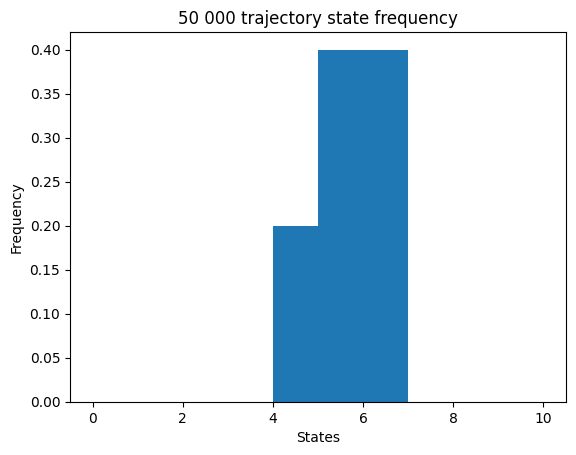

In [45]:
import matplotlib.pyplot as plt

nS = len(M[0])
#inital uniform distribution
u = np.ones((1, nS)) / nS
rnd.seed(42)
#long trajectory
traj = simulate(M, u, 50000)
print('End large trajectory: ', traj[-10:])

plt.figure()
plt.hist(x=np.array(traj).astype(int), bins=M[0], density=True)
plt.xlabel('States')
plt.ylabel('Frequency')
plt.title('50 000 trajectory state frequency')
u_star = stationary_dist(M)
print(u_star)
print(u_star.shape[0])
print(np.arange(0, nS))
plt.scatter(np.arange(0, nS), u_star, c='orange', label='Stationary values')

plt.show()